# Modelo de estimación de arriendo

Estima **en cuánto se podría arrendar** una propiedad a partir de sus atributos. Es la segunda de
las dos piezas del análisis de inversión: junto con el modelo de venta permite calcular el *yield*
—si el arriendo cubriría el dividendo hipotecario—, que se construye después.

Sigue el mismo marco hedónico y el mismo esquema de evaluación que `modelo_venta.ipynb`, con tres
diferencias de fondo:

| | Venta | **Arriendo** |
|---|---|---|
| Objetivo | `precio_uf` | **`precio_clp`** |
| Rango válido | 500 – 60.000 UF | **150.000 – 4.000.000 CLP** |
| Fuentes | portalinmobiliario únicamente | **dos portales de calidad muy distinta** |

Esa tercera diferencia es la que manda en todo el notebook: **el 23 % de los avisos de arriendo no
tiene coordenadas, ni año de construcción, ni gastos comunes, ni servicios cercanos.** No son
faltantes al azar sino una fuente entera sin esos campos, y por eso el diagnóstico por fuente
(Paso 7) es aquí tan importante como la métrica global.

## Marco teórico: el modelo hedónico

Se sigue el marco que revisa Owusu-Ansah (2011), *A Review of Hedonic Pricing Models in Housing
Research*.

**La idea de Rosen (1974)** es que una vivienda no se transa como un objeto único sino como un
**paquete de atributos**. El precio observado —aquí el arriendo pedido— revela los *precios
implícitos* de cada atributo: cuánto vale un metro cuadrado más, un baño más, estar a 300 metros
del metro en vez de a 1.200. Como esos atributos no se transan por separado, se estiman por
regresión.

El artículo agrupa los atributos en **tres bloques**, y el dataset tiene los tres:

| Bloque | Qué es | Variables |
|---|---|---|
| **Estructural** | La propiedad en sí | `m2_util`, `m2_total`, `dormitorios`, `banos`, `estacionamientos`, `bodegas`, `antiguedad` |
| **Ubicación** | Dónde está | `lat`, `lon`, `comuna` |
| **Vecindario** | Qué hay alrededor | Las 7 categorías de `servicios_cercanos` |

### La forma funcional

La forma **semi-logarítmica** que el artículo describe como la más empleada:

$$\ln Y_i = \beta_0 + \beta_1 X_i + \beta_2 Z_i + u_i$$

Citando a Follain y Malpezzi (1980), tiene tres ventajas: los coeficientes se leen como **cambio
porcentual**, permite que el valor monetario de cada atributo varíe con el nivel de precio, y
**reduce la heterocedasticidad**. Por eso todo se entrena sobre `log(precio_clp)` y se exponencia
al predecir.

### Por qué además árboles y no solo la regresión

El artículo concluye que los modelos **paramétricos** son fáciles de estimar e interpretar pero
*imponen supuestos fuertes que pueden dar resultados engañosos cuando se violan*; los **no
paramétricos** evitan esos supuestos pero *son computacionalmente técnicos y complicados*.

El gradient boosting cae del lado no paramétrico: no asume forma funcional, captura interacciones
—que 60 m² valen distinto en Ñuñoa que en La Florida— y **maneja los NaN de forma nativa**, que en
este dataset no es un detalle menor sino la razón de que se pueda entrenar con las dos fuentes a la
vez. Se incluye igualmente la **regresión log-lineal (Ridge)** como piso de comparación: es el
modelo del artículo.

In [1]:
import json
import sqlite3
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

SEMILLA = 42
ANIO = 2026
DB = Path("data/ofertas_unificado.sqlite")
MODELOS = Path("modelos"); MODELOS.mkdir(exist_ok=True)
COLORES = ["#0A6B67", "#8A3E5C", "#C08A2E", "#3B6EA5", "#6B7A3E"]
print(f"pandas {pd.__version__} - numpy {np.__version__}")

pandas 3.0.5 - numpy 2.5.2


## Paso 1 — Carga y limpieza

La misma limpieza validada en venta, con los rangos propios del arriendo: el centinela `SIN_DATO`
a `NaN`, los campos de antigüedad que venían intercambiados, los precios que quedaron sin convertir
y los valores imposibles anulados **sin descartar la fila**.

Una inversión respecto de venta: allá faltaban precios en UF y se reconstruían desde CLP; aquí el
objetivo **es** el CLP, así que la reconstrucción va en el otro sentido. Se usa la mediana empírica
de `precio_clp / precio_uf` sobre las filas que tienen ambos, no la UF de hoy: interesa la UF
vigente durante el scrape.

In [2]:
with sqlite3.connect(f"file:{DB.as_posix()}?mode=ro", uri=True, timeout=15) as con:
    crudo = pd.read_sql_query("SELECT * FROM ofertas WHERE operacion='arriendo'", con)

df = crudo.replace("SIN_DATO", pd.NA)
NUMERICAS = ["precio_uf", "precio_clp", "m2_util", "m2_total", "dormitorios", "banos",
             "estacionamientos", "bodegas", "ano_construccion", "antiguedad_anos",
             "gastos_comunes_clp", "lat", "lon"]
for c in NUMERICAS:
    df[c] = pd.to_numeric(df[c], errors="coerce")
print(f"arriendo: {len(df):,} avisos")

# --- Reparaciones (recuperan dato, no lo descartan) --------------------------
swap = df["ano_construccion"].between(0, 60) & df["antiguedad_anos"].between(1900, 2030)
df.loc[swap, ["ano_construccion", "antiguedad_anos"]] = \
    df.loc[swap, ["antiguedad_anos", "ano_construccion"]].to_numpy()

ambos = df["precio_clp"].notna() & df["precio_uf"].notna() & (df["precio_uf"] > 0)
UF = float((df.loc[ambos, "precio_clp"] / df.loc[ambos, "precio_uf"]).median())
falta = df["precio_clp"].isna() & df["precio_uf"].notna()
df.loc[falta, "precio_clp"] = df.loc[falta, "precio_uf"] * UF
print(f"  campos de antiguedad intercambiados, reparados : {int(swap.sum()):,}")
print(f"  precios reconstruidos con UF = {UF:,.2f}          : {int(falta.sum()):,}")

# --- Anulaciones (valor imposible, la fila se conserva) ----------------------
RANGOS = {"estacionamientos": (0, 10), "bodegas": (0, 10), "dormitorios": (0, 10),
          "banos": (1, 12), "ano_construccion": (1900, 2030),
          "gastos_comunes_clp": (0, 3_000_000)}
for col, (lo, hi) in RANGOS.items():
    df.loc[df[col].notna() & ~df[col].between(lo, hi), col] = np.nan
df.loc[df["m2_total"].notna() & (df["m2_util"] > df["m2_total"]), "m2_total"] = np.nan
df.loc[(df["tipo"] == "departamento") & (df["gastos_comunes_clp"] == 0),
       "gastos_comunes_clp"] = np.nan

# --- Filtro final de rango: lo unico que descarta filas ----------------------
# 150.000 CLP descarta piezas y estacionamientos sueltos; 4.000.000 descarta los
# avisos que en realidad son precio de venta mal etiquetado.
antes = len(df)
df = df[df["precio_clp"].between(150_000, 4_000_000) & df["m2_util"].between(15, 600)].copy()
print(f"\ntras el filtro de rango: {len(df):,} avisos (se descartan {antes-len(df)})")
print(f"  {df['tipo'].value_counts().to_dict()}")
print(f"  arriendo mediano: ${df['precio_clp'].median():,.0f}")

arriendo: 5,835 avisos
  campos de antiguedad intercambiados, reparados : 66
  precios reconstruidos con UF = 40,844.79          : 55

tras el filtro de rango: 5,662 avisos (se descartan 173)
  {'departamento': 5462, 'casa': 200}
  arriendo mediano: $480,000


## Paso 2 — Las dos poblaciones del conjunto de arriendo

Antes de construir nada hay que mirar de frente el problema propio de este dataset. Los avisos
vienen de dos portales y **no aportan los mismos campos**. La tabla siguiente no es un chequeo de
rutina: determina qué se puede modelar y cómo hay que leer las métricas después.

% de avisos con el campo informado, por fuente
(pi = portalinmobiliario, 4,359 avisos - cp = chilepropiedades, 1,303 avisos)

sitio                  cp     pi
m2_util             100.0  100.0
m2_total              0.0   95.0
dormitorios          98.8   73.8
banos                99.5   93.0
estacionamientos     50.3   43.2
bodegas               0.0   95.9
ano_construccion      0.0   73.5
gastos_comunes_clp    0.0   87.9
lat                   0.0   98.8
lon                   0.0   98.8
servicios_cercanos    0.0   98.8

23.9% del conjunto no tiene coordenadas, y practicamente el mismo
conjunto de filas es el que carece de servicios cercanos, antiguedad y gastos
comunes. No es un faltante al azar: es una fuente entera sin esos campos.

casas 200 contra 5,462 departamentos: el modelo va a saber
muy poco de casas, y eso hay que declararlo en el producto.


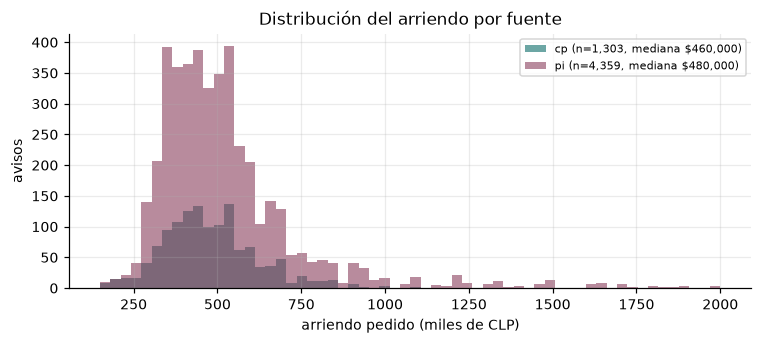

In [3]:
CAMPOS = ["m2_util", "m2_total", "dormitorios", "banos", "estacionamientos", "bodegas",
          "ano_construccion", "gastos_comunes_clp", "lat", "lon", "servicios_cercanos"]

cobertura = (df.assign(**{c: df[c].notna() for c in CAMPOS})
               .groupby("sitio")[CAMPOS].mean().mul(100).round(1).T)
print("% de avisos con el campo informado, por fuente")
print(f"(pi = portalinmobiliario, {int((df['sitio']=='pi').sum()):,} avisos - "
      f"cp = chilepropiedades, {int((df['sitio']=='cp').sum()):,} avisos)\n")
print(cobertura.to_string())

sin_geo_pct = 100 * df["lat"].isna().mean()
print(f"\n{sin_geo_pct:.1f}% del conjunto no tiene coordenadas, y practicamente el mismo")
print("conjunto de filas es el que carece de servicios cercanos, antiguedad y gastos")
print("comunes. No es un faltante al azar: es una fuente entera sin esos campos.")
print(f"\ncasas {int((df['tipo']=='casa').sum()):,} contra "
      f"{int((df['tipo']=='departamento').sum()):,} departamentos: el modelo va a saber")
print("muy poco de casas, y eso hay que declararlo en el producto.")

fig, ax = plt.subplots(figsize=(7, 3.2))
for i, (s, g) in enumerate(df.groupby("sitio")):
    ax.hist(g["precio_clp"] / 1000, bins=60, range=(150, 2000), alpha=0.6,
            label=f"{s} (n={len(g):,}, mediana ${g['precio_clp'].median():,.0f})",
            color=COLORES[i])
ax.set_xlabel("arriendo pedido (miles de CLP)"); ax.set_ylabel("avisos")
ax.set_title("Distribución del arriendo por fuente"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## Paso 3 — Las variables, en los tres bloques de Rosen

El JSON de `servicios_cercanos` se abre en columnas numéricas: para cada categoría, la **distancia
al más cercano** y **cuántos hay en un kilómetro**. La distancia es exacta —la API devuelve los
lugares ordenados por cercanía—, pero el conteo está **censurado** donde los 20 resultados de la
consulta se llenaron; por eso entra `servicios_truncado`, para que el modelo sepa cuándo el conteo
es un piso y no el total.

**Dos variables que no existen en el modelo de venta:** `sin_geo` y `sin_servicios`. Marcan las
filas de la fuente incompleta. La decisión de fondo es **entrenar con todo y declarar la ausencia**
en vez de descartar el 23 % del conjunto o entrenar dos modelos: los árboles manejan el NaN de
forma nativa, y la ausencia es en sí misma información —identifica el tipo de aviso y correlaciona
con cómo se publica—. Las dos son casi idénticas entre sí (la misma fuente carece de ambas cosas);
se dejan separadas porque un aviso nuevo llegado a la API sí puede tener coordenadas sin tener
servicios consultados.

`sitio` **no entra como variable** aunque sería predictiva: la API no puede saber de qué portal
vendría un aviso nuevo. Se conserva solo para diagnosticar.

In [4]:
CATEGORIAS_POI = ["metro", "salud", "comercio", "universidad",
                  "educacion", "parque", "supermercado"]


def abrir_servicios(serie):
    """El JSON de servicios_cercanos -> columnas numericas."""
    filas = []
    for s in serie:
        d = {}
        if isinstance(s, str) and s not in ("", "SIN_DATO"):
            j = json.loads(s)
            for cat in CATEGORIAS_POI:
                v = j.get(cat)
                d[f"dist_{cat}_m"] = v["mas_cercano_m"] if v else np.nan
                d[f"n_{cat}_1km"] = v["n_1km"] if v else np.nan
            d["servicios_truncado"] = float(j.get("_truncado", False))
        else:
            for cat in CATEGORIAS_POI:
                d[f"dist_{cat}_m"] = np.nan
                d[f"n_{cat}_1km"] = np.nan
            d["servicios_truncado"] = np.nan
        filas.append(d)
    return pd.DataFrame(filas, index=serie.index)


def construir_features(d):
    """Las tres familias de atributos del marco hedonico, mas los indicadores de ausencia."""
    d = d.copy()
    dorm = d["dormitorios"].fillna(1).clip(lower=1)

    # --- estructurales ---
    d["antiguedad"] = ANIO - d["ano_construccion"]
    d["log_m2_util"] = np.log(d["m2_util"])
    d["ratio_terraza"] = ((d["m2_total"] - d["m2_util"]) / d["m2_total"]).where(
        d["m2_total"].notna() & (d["m2_total"] > 0))
    d["m2_por_dormitorio"] = d["m2_util"] / dorm
    d["densidad_banos"] = d["banos"] / dorm
    d["es_casa"] = (d["tipo"] == "casa").astype(float)
    d["tiene_estacionamiento"] = (d["estacionamientos"].fillna(0) > 0).astype(float)
    d["tiene_bodega"] = (d["bodegas"].fillna(0) > 0).astype(float)

    # --- ubicacion y vecindario ---
    d["sin_geo"] = (d["lat"].isna() | d["lon"].isna()).astype(float)
    d = pd.concat([d, abrir_servicios(d["servicios_cercanos"])], axis=1)
    d["sin_servicios"] = d[f"dist_{CATEGORIAS_POI[0]}_m"].isna().astype(float)
    # El logaritmo de la distancia captura mejor el efecto: pasar de 100 a 300 m
    # del metro pesa mucho mas que pasar de 1.100 a 1.300 m.
    for cat in CATEGORIAS_POI:
        d[f"log_dist_{cat}"] = np.log1p(d[f"dist_{cat}_m"])
    return d


datos = construir_features(df)

ESTRUCTURALES = ["m2_util", "log_m2_util", "m2_total", "ratio_terraza", "dormitorios",
                 "banos", "densidad_banos", "m2_por_dormitorio", "estacionamientos",
                 "bodegas", "tiene_estacionamiento", "tiene_bodega", "antiguedad",
                 "gastos_comunes_clp", "es_casa"]
UBICACION_NUM = ["lat", "lon", "sin_geo"]
UBICACION_CAT = ["comuna"]
VECINDARIO = ([f"log_dist_{c}" for c in CATEGORIAS_POI]
              + [f"n_{c}_1km" for c in CATEGORIAS_POI]
              + ["servicios_truncado", "sin_servicios"])

NUM = ESTRUCTURALES + UBICACION_NUM + VECINDARIO
TODAS = NUM + UBICACION_CAT

# Nada que sea el precio, ni una funcion del precio, ni consecuencia de el.
# `antiguedad_aviso_dias` es consecuencia: un aviso lleva 300 dias publicado PORQUE
# esta caro. `sitio` no es fuga, pero la API no sabria de que portal viene un aviso.
PROHIBIDAS = {"precio_uf", "precio_clp", "precio_valor", "antiguedad_aviso_dias",
              "fecha_publicacion", "fecha_scrape", "uf_por_m2", "sitio"}
assert not set(TODAS) & PROHIBIDAS, "hay una columna prohibida entre las features"

print(f"{len(TODAS)} variables en tres bloques:")
print(f"  estructurales : {len(ESTRUCTURALES):>2}")
print(f"  ubicacion     : {len(UBICACION_NUM)+len(UBICACION_CAT):>2}")
print(f"  vecindario    : {len(VECINDARIO):>2}")
print("\n% de valores faltantes por bloque:")
for nombre, cols in [("estructurales", ESTRUCTURALES), ("ubicacion", UBICACION_NUM),
                     ("vecindario", VECINDARIO)]:
    print(f"  {nombre:<14} {100*datos[cols].isna().mean().mean():.1f}%")

35 variables en tres bloques:
  estructurales : 15
  ubicacion     :  4
  vecindario    : 16

% de valores faltantes por bloque:
  estructurales  16.1%
  ubicacion      16.0%
  vecindario     23.0%


## Paso 4 — La división 80/20

80 % para entrenar, 20 % para evaluar, **no dividido al azar por filas**: buena parte de los avisos
comparte coordenada exacta con otro porque son departamentos del mismo edificio. Con una división
aleatoria casi toda torre grande queda partida entre entrenamiento y prueba, y el modelo podría
acertar por haber memorizado el precio de esa torre en vez de haber entendido el mercado.

El agrupador es la coordenada redondeada a 4 decimales (~11 m), con cascada a **dirección
normalizada** y luego a un identificador propio. Esa cascada pesa aquí mucho más que en venta: las
filas sin coordenadas —la fuente incompleta— caen todas al segundo o tercer nivel, así que buena
parte del agrupamiento del conjunto de arriendo descansa sobre el texto de la dirección.

En el Paso 7 se mide qué habría pasado con la división aleatoria. Es una pregunta empírica: en
venta la diferencia resultó estar dentro del ruido, contra lo que se esperaba.

In [5]:
datos = datos.reset_index(drop=True)

geo_ok = datos["lat"].notna() & datos["lon"].notna()
grupo = pd.Series(index=datos.index, dtype="object")
grupo[geo_ok] = ("g:" + datos.loc[geo_ok, "lat"].map("{:.4f}".format)
                 + "," + datos.loc[geo_ok, "lon"].map("{:.4f}".format))
sin_geo = ~geo_ok
if sin_geo.any():
    dirs = (datos.loc[sin_geo, "direccion"].fillna("").astype(str)
            .str.lower().str.strip().str.replace(r"\s+", " ", regex=True))
    grupo[sin_geo] = np.where(dirs != "", "d:" + dirs,
                              [f"u:{i}" for i in datos.index[sin_geo]])
datos["edificio"] = grupo

y = datos["precio_clp"].to_numpy(float)
X = datos[TODAS]

separador = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEMILLA)
i_train, i_test = next(separador.split(X, y, groups=datos["edificio"]))

# Version aleatoria, solo para comparar despues
i_train_al, i_test_al = train_test_split(np.arange(len(X)), test_size=0.20,
                                         random_state=SEMILLA)

print(f"total          : {len(X):,} avisos en {datos['edificio'].nunique():,} grupos\n")
print(f"ENTRENAMIENTO  : {len(i_train):,} ({100*len(i_train)/len(X):.1f}%)")
print(f"PRUEBA         : {len(i_test):,} ({100*len(i_test)/len(X):.1f}%)")

cruce = set(datos.loc[i_train, "edificio"]) & set(datos.loc[i_test, "edificio"])
print(f"\ngrupos que aparecen en ambos lados: {len(cruce)}   "
      f"{'CORRECTO' if not cruce else 'HAY FUGA'}")
cruce_al = set(datos.loc[i_train_al, "edificio"]) & set(datos.loc[i_test_al, "edificio"])
print(f"   con division aleatoria serian: {len(cruce_al):,}")

print("\nreparto de la fuente incompleta (cp) entre los dos lados:")
for nombre, idx in [("train", i_train), ("test", i_test)]:
    s = datos.loc[idx, "sitio"].value_counts(normalize=True).mul(100).round(1).to_dict()
    print(f"  {nombre:<6} {s}")
print(f"\narriendo mediano  train ${np.median(y[i_train]):>9,.0f}   "
      f"test ${np.median(y[i_test]):>9,.0f}")

total          : 5,662 avisos en 3,451 grupos

ENTRENAMIENTO  : 4,419 (78.0%)
PRUEBA         : 1,243 (22.0%)

grupos que aparecen en ambos lados: 0   CORRECTO
   con division aleatoria serian: 326

reparto de la fuente incompleta (cp) entre los dos lados:
  train  {'pi': 76.0, 'cp': 24.0}
  test   {'pi': 80.5, 'cp': 19.5}

arriendo mediano  train $  480,000   test $  460,000


## Paso 5 — Cómo se mide

Las métricas del estándar de tasación masiva (IAAO), no las habituales de ML. En tasación se usa la
**mediana** y no el promedio porque unas pocas propiedades atípicas distorsionan cualquier media.

| Métrica | Qué mide | Referencia |
|---|---|---|
| **MdAPE** | Error porcentual absoluto mediano | < 15 % bueno, < 10 % excelente |
| **PPE10** | % de estimaciones dentro de ±10 % | > 50 % |
| **COD** | Uniformidad: dispersión de los ratios | 5 – 15 |
| **PRD** | Sesgo vertical: ¿sobrevalora los arriendos baratos? | 0,98 – 1,03 |

Todas se calculan en **pesos**, nunca en logaritmos: un R² de 0,9 sobre `log(precio)` puede
esconder un error enorme en dinero.

Se añade un **piso de referencia**: predecir a todos con la mediana del entrenamiento. En el
diagnóstico de `clustering.ipynb` ese piso daba ~20 % en arriendo contra ~36 % en venta —los
arriendos están mucho más estandarizados—, y por eso aquí se espera un MdAPE mejor que el 8,78 %
del modelo de venta. Si sale peor, algo está mal.

In [6]:
def evaluar(y_real, y_pred):
    y, p = np.asarray(y_real, float), np.asarray(y_pred, float)
    ok = np.isfinite(y) & np.isfinite(p) & (y > 0)
    y, p = y[ok], p[ok]
    ape = 100 * np.abs(p - y) / y
    r = p / y
    med = np.median(r)
    return {
        "n": len(y),
        "MdAPE": float(np.median(ape)),
        "PPE10": float(100 * np.mean(ape <= 10 + 1e-9)),
        "PPE20": float(100 * np.mean(ape <= 20 + 1e-9)),
        "COD": float(100 * np.mean(np.abs(r - med)) / med),
        "PRD": float(np.mean(r) / (p.sum() / y.sum())),
        "R2": float(1 - ((y - p) ** 2).sum() / ((y - y.mean()) ** 2).sum()),
        "MAE_CLP": float(np.mean(np.abs(p - y))),
    }


# Verificacion con un caso de valor conocido: cuatro errores de exactamente 10%
_c = evaluar([100, 200, 300, 400], [110, 180, 330, 360])
assert abs(_c["MdAPE"] - 10) < 1e-9 and abs(_c["PPE10"] - 100) < 1e-9
assert abs(_c["COD"] - 10) < 1e-9 and abs(_c["PRD"] - 1 / 0.98) < 1e-9
print(f"metricas verificadas con el caso canonico: MdAPE {_c['MdAPE']:.1f} - "
      f"PPE10 {_c['PPE10']:.0f} - COD {_c['COD']:.1f} - PRD {_c['PRD']:.4f}")

base = evaluar(y[i_test], np.full(len(i_test), np.median(y[i_train])))
print(f"\npiso (predecir siempre la mediana): MdAPE {base['MdAPE']:.1f}% - "
      f"PPE10 {base['PPE10']:.1f}%")

metricas verificadas con el caso canonico: MdAPE 10.0 - PPE10 100 - COD 10.0 - PRD 1.0204

piso (predecir siempre la mediana): MdAPE 20.3% - PPE10 24.4%


## Paso 6 — Los modelos

Todos comparten la misma estructura de tres capas, y esa envoltura resuelve dos problemas de raíz:

```
TransformedTargetRegressor(log / exp)   <- predict() devuelve CLP, nunca logaritmos
  Pipeline
    ColumnTransformer                   <- imputa y codifica, ajustado SOLO con el train
    estimador
```

Que la imputación viva dentro del pipeline no es estilo: si se imputara antes de dividir, la
mediana del conjunto de prueba se filtraría al de entrenamiento. Y `remainder="drop"` garantiza que
ninguna columna no declarada llegue al estimador por descuido.

Los modelos de árboles reciben los NaN **sin imputar** —los manejan de forma nativa y aprenden por
qué lado mandar al faltante—, que es justamente lo que hace viable entrenar con las dos fuentes
juntas. Ridge sí necesita imputación y escalado, y por eso parte en desventaja en este dataset
concreto: al imputarle la mediana al 23 % sin coordenadas se le está inventando una ubicación.

Sobre la retransformación: `exp(media de logaritmos)` estima la **mediana** condicional, que es
exactamente lo que miden MdAPE y PPE10. Por eso no se aplica corrección de smearing de Duan
—mejoraría el sesgo en media y empeoraría la métrica que importa—.

**El ganador no se elige solo por MdAPE.** El estándar IAAO pide también equidad vertical, y las
diferencias de MdAPE entre los primeros clasificados están dentro del ruido. La regla es: entre los
modelos que quedan a menos de 0,25 puntos del mejor MdAPE, gana el de **PRD más cercano a 1**.

In [7]:
def preprocesador(imputar_y_escalar):
    """imputar_y_escalar=True para modelos lineales; False deja el NaN a los arboles."""
    if imputar_y_escalar:
        pipe_num = Pipeline([("imputar", SimpleImputer(strategy="median", add_indicator=True)),
                             ("escalar", StandardScaler())])
    else:
        pipe_num = "passthrough"
    return ColumnTransformer(
        [("num", pipe_num, NUM),
         ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), UBICACION_CAT)],
        remainder="drop")   # nada entra por accidente


def envolver(estimador, imputar):
    interno = Pipeline([("prep", preprocesador(imputar)), ("modelo", estimador)])
    return TransformedTargetRegressor(regressor=interno, func=np.log,
                                      inverse_func=np.exp, check_inverse=False)


CANDIDATOS = {
    "ridge (log-lineal del articulo)": envolver(Ridge(alpha=1.0), True),
    "random_forest": envolver(RandomForestRegressor(
        n_estimators=400, min_samples_leaf=2, max_features="sqrt",
        n_jobs=-1, random_state=SEMILLA), True),
    "hist_gradient": envolver(HistGradientBoostingRegressor(
        max_iter=500, learning_rate=0.06, max_leaf_nodes=31, min_samples_leaf=20,
        l2_regularization=1.0, random_state=SEMILLA), False),
}

try:
    from xgboost import XGBRegressor
    CANDIDATOS["xgboost"] = envolver(XGBRegressor(
        n_estimators=600, learning_rate=0.05, max_depth=6, subsample=0.8,
        colsample_bytree=0.8, min_child_weight=5, reg_lambda=1.0,
        n_jobs=-1, random_state=SEMILLA, tree_method="hist"), False)
except ImportError:
    pass
try:
    from lightgbm import LGBMRegressor
    CANDIDATOS["lightgbm"] = envolver(LGBMRegressor(
        n_estimators=700, learning_rate=0.05, num_leaves=31, min_child_samples=20,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0,
        n_jobs=-1, random_state=SEMILLA, verbose=-1), False)
except ImportError:
    pass

print(f"{len(CANDIDATOS)} modelos a comparar: {list(CANDIDATOS)}")

5 modelos a comparar: ['ridge (log-lineal del articulo)', 'random_forest', 'hist_gradient', 'xgboost', 'lightgbm']


In [8]:
X_train, X_test = X.iloc[i_train], X.iloc[i_test]
y_train, y_test = y[i_train], y[i_test]

resultados, entrenados = [], {}
for nombre, modelo in CANDIDATOS.items():
    t0 = time.perf_counter()
    modelo.fit(X_train, y_train)
    seg = time.perf_counter() - t0
    m = evaluar(y_test, modelo.predict(X_test))
    m["modelo"], m["seg"] = nombre, round(seg, 1)
    resultados.append(m)
    entrenados[nombre] = modelo
    print(f"  {nombre:<32} MdAPE {m['MdAPE']:5.2f}%  PPE10 {m['PPE10']:5.1f}%  [{seg:.1f}s]")

COLS_TABLA = ["n", "MdAPE", "PPE10", "PPE20", "COD", "PRD", "R2", "MAE_CLP", "seg"]
tabla = (pd.DataFrame(resultados).set_index("modelo")[COLS_TABLA]
         .sort_values("MdAPE").round(3))
print(f"\n{'='*104}\nRESULTADOS SOBRE EL 20% DE PRUEBA (edificios nunca vistos)\n{'='*104}")
print(tabla.to_string())

# La seleccion no es solo por MdAPE. El estandar IAAO exige ademas equidad
# vertical (PRD), y aqui las diferencias de MdAPE entre los primeros son ruido:
# entre los que quedan a menos de 0,25 puntos del mejor, gana el de PRD mas
# cercano a 1. Elegir por MdAPE a secas daria un modelo mas regresivo a cambio
# de una centesima de error mediano.
cerca = tabla[tabla["MdAPE"] <= tabla["MdAPE"].min() + 0.25]
GANADOR = (cerca["PRD"] - 1).abs().idxmin()
modelo_final = entrenados[GANADOR]

print(f"\nempatados dentro de 0,25 puntos de MdAPE : {list(cerca.index)}")
print(f"de esos, el de PRD mas cercano a 1        : {GANADOR}")
print(f"\nGanador: {GANADOR}   MdAPE {tabla.loc[GANADOR,'MdAPE']:.2f}%   "
      f"PRD {tabla.loc[GANADOR,'PRD']:.3f}")
print(f"contra el piso de {base['MdAPE']:.1f}% de predecir siempre la mediana.")
if tabla.loc[GANADOR, "MdAPE"] < 5:
    print("\nATENCION: un MdAPE bajo 5% es sospechoso de fuga. Auditar antes de celebrar.")

  ridge (log-lineal del articulo)  MdAPE  7.95%  PPE10  59.5%  [0.1s]


  random_forest                    MdAPE  7.73%  PPE10  60.3%  [1.0s]


  hist_gradient                    MdAPE  8.17%  PPE10  58.2%  [3.9s]


  xgboost                          MdAPE  7.75%  PPE10  59.9%  [2.2s]


  lightgbm                         MdAPE  8.26%  PPE10  57.6%  [1.8s]

RESULTADOS SOBRE EL 20% DE PRUEBA (edificios nunca vistos)
                                    n  MdAPE   PPE10   PPE20     COD    PRD     R2    MAE_CLP  seg
modelo                                                                                            
random_forest                    1243  7.730  60.338  85.680  11.553  1.046  0.742  65097.556  1.0
xgboost                          1243  7.750  59.855  86.002  11.620  1.032  0.804  62908.202  2.2
ridge (log-lineal del articulo)  1243  7.953  59.453  85.036  12.338  1.041  0.723  68897.284  0.1
hist_gradient                    1243  8.165  58.166  85.841  11.802  1.031  0.817  62652.840  3.9
lightgbm                         1243  8.261  57.603  85.278  12.056  1.031  0.803  64761.455  1.8

empatados dentro de 0,25 puntos de MdAPE : ['random_forest', 'xgboost', 'ridge (log-lineal del articulo)']
de esos, el de PRD mas cercano a 1        : xgboost

Ganador: xgboost

## Paso 7 — ¿Cuánto habría inflado la división aleatoria?

Se reentrena el ganador con la división aleatoria por filas —la que reparte los edificios entre
entrenamiento y prueba— y se compara. La diferencia mide cuánto se estaría engañando uno al usarla.

Es una comprobación, no una conclusión anticipada: en venta salió que la aleatoria no inflaba nada
apreciable, contra lo que se esperaba. Aquí puede salir distinto, porque el agrupamiento de las
filas sin coordenadas depende del texto de la dirección y es más frágil.

In [9]:
modelo_al = CANDIDATOS[GANADOR].__class__(
    regressor=CANDIDATOS[GANADOR].regressor, func=np.log, inverse_func=np.exp,
    check_inverse=False)
modelo_al.fit(X.iloc[i_train_al], y[i_train_al])
m_al = evaluar(y[i_test_al], modelo_al.predict(X.iloc[i_test_al]))
m_gr = tabla.loc[GANADOR]

comp = pd.DataFrame({
    "agrupado por edificio": [m_gr["MdAPE"], m_gr["PPE10"], m_gr["COD"]],
    "aleatorio por filas":   [m_al["MdAPE"], m_al["PPE10"], m_al["COD"]],
}, index=["MdAPE", "PPE10", "COD"]).round(2)
comp["diferencia"] = (comp["aleatorio por filas"] - comp["agrupado por edificio"]).round(2)
print(comp.to_string())

d = float(m_gr["MdAPE"]) - float(m_al["MdAPE"])
print(f"\ndiferencia en MdAPE: {d:+.2f} puntos a favor de la division aleatoria")
if d > 0.5:
    print("\nLa aleatoria SI infla de forma apreciable: parte de su ventaja viene de")
    print("reconocer edificios que ya habia visto, no de predecir mejor. La cifra")
    print("que se reporta es la agrupada.")
elif d > 0.05:
    print("\nLa aleatoria infla, pero poco. El modelo no depende de memorizar")
    print("edificios: se apoya en los atributos y en la ubicacion gruesa.")
else:
    print("\nLa aleatoria NO resulto mejor: la diferencia esta dentro del ruido.")
    print("Es un resultado a favor del modelo. Solo se puede afirmar porque se")
    print("midieron las dos divisiones.")

       agrupado por edificio  aleatorio por filas  diferencia
MdAPE                   7.75                 7.19       -0.56
PPE10                  59.86                61.52        1.66
COD                    11.62                10.99       -0.63

diferencia en MdAPE: +0.56 puntos a favor de la division aleatoria

La aleatoria SI infla de forma apreciable: parte de su ventaja viene de
reconocer edificios que ya habia visto, no de predecir mejor. La cifra
que se reporta es la agrupada.


## Paso 8 — Diagnóstico del ganador

Cuatro cortes. Los tres primeros son los de siempre —comuna, tipo, rango de precio—; el cuarto es
**el que decide qué hacer con chilepropiedades** y es la razón de ser de este notebook.

Si el error en `cp` resulta mucho peor que en `pi`, hay que decidir si esos avisos se excluyen del
entrenamiento o si se marcan como de baja confianza en el producto. La decisión es del dueño del
proyecto con el número a la vista; aquí solo se produce el número.

In [10]:
pred_test = modelo_final.predict(X_test)
prueba = datos.iloc[i_test].copy()
prueba["pred"] = pred_test
prueba["ape"] = 100 * np.abs(pred_test - y_test) / y_test
prueba["ratio"] = pred_test / y_test

def resumen(g):
    return pd.Series({"n": len(g), "MdAPE": g["ape"].median(),
                      "PPE10": 100 * (g["ape"] <= 10).mean(),
                      "ratio_mediano": g["ratio"].median()})

for col in ["comuna", "tipo", "sitio"]:
    r = prueba.groupby(col).apply(resumen, include_groups=False).round(2).sort_values("MdAPE")
    etiqueta = "FUENTE (pi=portalinmobiliario, cp=chilepropiedades)" if col == "sitio" else col
    print(f"\n=== error por {etiqueta} ===")
    print(r.to_string())

prueba["rango"] = pd.qcut(y_test, 5, labels=["muy barato", "barato", "medio",
                                             "caro", "muy caro"])
r = prueba.groupby("rango", observed=True).apply(
    lambda g: pd.Series({"n": len(g), "arriendo_mediano": g["precio_clp"].median(),
                         "MdAPE": g["ape"].median(), "ratio_mediano": g["ratio"].median()}),
    include_groups=False).round(2)
print("\n=== error por rango de precio (sesgo vertical) ===")
print(r.to_string())
print("\nSi el ratio bajara al subir el precio, el modelo seria regresivo:")
print("sobrevaloraria los arriendos baratos y subvaloraria los caros.")


=== error por comuna ===
                n  MdAPE  PPE10  ratio_mediano
comuna                                        
macul       234.0   6.59  68.80           1.00
san-miguel  263.0   7.93  57.41           1.00
la-florida  371.0   8.10  58.22           1.00
nunoa       375.0   8.44  57.60           1.01

=== error por tipo ===
                   n  MdAPE  PPE10  ratio_mediano
tipo                                             
departamento  1197.0   7.63  60.40           1.00
casa            46.0  11.81  45.65           0.97

=== error por FUENTE (pi=portalinmobiliario, cp=chilepropiedades) ===
            n  MdAPE  PPE10  ratio_mediano
sitio                                     
pi     1001.0   7.29  62.24            1.0
cp      242.0   9.91  50.00            1.0

=== error por rango de precio (sesgo vertical) ===
                n  arriendo_mediano  MdAPE  ratio_mediano
rango                                                    
muy barato  267.0          329000.0   8.89           1.04

In [11]:
# La lectura del corte por fuente, con el numero a la vista.
por_sitio = prueba.groupby("sitio").apply(resumen, include_groups=False)
mp = float(por_sitio.loc["pi", "MdAPE"]); mc = float(por_sitio.loc["cp", "MdAPE"])
print(f"MdAPE pi {mp:.2f}%   MdAPE cp {mc:.2f}%   brecha {mc-mp:+.2f} puntos\n")
if mc - mp > 4:
    print("La fuente incompleta se estima MUCHO peor. Hay que decidir entre excluirla")
    print("del entrenamiento o marcarla de baja confianza en el producto: con solo")
    print("comuna, tipo, superficie, dormitorios y banos no hay como afinar mas.")
elif mc - mp > 1.5:
    print("La fuente incompleta se estima peor, de forma apreciable pero no ruinosa.")
    print("Justifica marcar de menor confianza las estimaciones sin geo, no excluirlas.")
else:
    print("La fuente incompleta NO se estima apreciablemente peor. Es un resultado")
    print("negativo util: los cinco campos que si trae (comuna, tipo, superficie,")
    print("dormitorios, banos) llevan casi toda la senal del arriendo, y los campos")
    print("que faltan aportaban menos de lo que su ausencia hacia temer.")

# La comparacion honesta exige tambien mirar si son poblaciones distintas: si `cp`
# fuera sistematicamente mas barato y homogeneo, su MdAPE seria mejor por facilidad,
# no por merito del modelo.
print("\ncontexto: no son la misma poblacion")
print(df.groupby("sitio")["precio_clp"].describe()[["count", "25%", "50%", "75%"]]
        .round(0).to_string())

MdAPE pi 7.29%   MdAPE cp 9.91%   brecha +2.62 puntos

La fuente incompleta se estima peor, de forma apreciable pero no ruinosa.
Justifica marcar de menor confianza las estimaciones sin geo, no excluirlas.

contexto: no son la misma poblacion
        count       25%       50%       75%
sitio                                      
cp     1303.0  380000.0  460000.0  560000.0
pi     4359.0  390000.0  480000.0  590226.0


### El sesgo vertical no se arregla cambiando de algoritmo

El corte por rango de precio muestra el problema más serio de este modelo: el ratio
estimado/real **baja al subir el precio**. El modelo es *regresivo* —sobrevalora los arriendos
baratos y subvalora los caros—, y el PRD lo confirma quedando por encima de la banda IAAO de
0,98–1,03.

Antes de declararlo como límite hay que descartar que sea un artefacto del algoritmo o de los
hiperparámetros. Se prueban variantes en las dos direcciones plausibles: **más capacidad** (hojas
más pequeñas, más profundidad, más variables por corte), que reduciría la contracción hacia la
media, y **quitar la transformación logarítmica**, por si la retransformación fuera la culpable.

In [12]:
def sin_log(estimador, imputar):
    """El mismo pipeline pero SIN la transformacion logaritmica del objetivo."""
    return Pipeline([("prep", preprocesador(imputar)), ("modelo", estimador)])


variantes = {
    "rf hojas de 1": envolver(RandomForestRegressor(
        n_estimators=400, min_samples_leaf=1, max_features="sqrt",
        n_jobs=-1, random_state=SEMILLA), True),
    "rf max_features 0.5": envolver(RandomForestRegressor(
        n_estimators=400, min_samples_leaf=2, max_features=0.5,
        n_jobs=-1, random_state=SEMILLA), True),
    "rf SIN log": sin_log(RandomForestRegressor(
        n_estimators=400, min_samples_leaf=2, max_features="sqrt",
        n_jobs=-1, random_state=SEMILLA), True),
}
if "XGBRegressor" in dir():
    variantes["xgb mas profundo"] = envolver(XGBRegressor(
        n_estimators=900, learning_rate=0.04, max_depth=8, subsample=0.9,
        colsample_bytree=0.9, min_child_weight=2, reg_lambda=0.5,
        n_jobs=-1, random_state=SEMILLA, tree_method="hist"), False)
    variantes["xgb SIN log"] = sin_log(XGBRegressor(
        n_estimators=600, learning_rate=0.05, max_depth=6, subsample=0.8,
        colsample_bytree=0.8, min_child_weight=5, reg_lambda=1.0,
        n_jobs=-1, random_state=SEMILLA, tree_method="hist"), False)

quintil = pd.qcut(y_test, 5, labels=False)


def perfil_vertical(p):
    r = evaluar(y_test, p)
    ratio = p / y_test
    return {"MdAPE": r["MdAPE"], "COD": r["COD"], "PRD": r["PRD"],
            "ratio_20%_mas_barato": float(np.median(ratio[quintil == 0])),
            "ratio_20%_mas_caro": float(np.median(ratio[quintil == 4]))}


perfiles = {n: perfil_vertical(m.predict(X_test)) for n, m in entrenados.items()}
for n, m in variantes.items():
    m.fit(X_train, y_train)
    perfiles[f"* {n}"] = perfil_vertical(m.predict(X_test))

vertical = pd.DataFrame(perfiles).T.round(3).sort_values("PRD")
print("los marcados con * son variantes probadas solo para este chequeo\n")
print(vertical.to_string())

mejor_prd = float(vertical["PRD"].min())
print(f"\nel PRD mas bajo alcanzado por cualquier variante es {mejor_prd:.3f}; "
      f"la banda IAAO pide 0,98-1,03.")
print("Ni mas capacidad ni quitar el logaritmo lo meten en banda: la regresividad")
print("es del dataset, no del algoritmo. El quintil mas caro son arriendos sobre")
print("~700.000 CLP, un tramo delgado y heterogeneo (unidades grandes, casas,")
print("amoblados que el aviso no distingue), y ahi cualquier modelo contrae hacia")
print("la media. Se declara como sesgo conocido en la ficha en vez de disimularlo.")

los marcados con * son variantes probadas solo para este chequeo

                                 MdAPE     COD    PRD  ratio_20%_mas_barato  ratio_20%_mas_caro
hist_gradient                    8.165  11.802  1.031                 1.052               0.945
lightgbm                         8.261  12.056  1.031                 1.028               0.944
xgboost                          7.750  11.620  1.032                 1.044               0.940
* xgb SIN log                    7.817  11.985  1.033                 1.072               0.945
* xgb mas profundo               8.146  12.122  1.035                 1.054               0.940
* rf max_features 0.5            7.744  11.815  1.040                 1.048               0.923
ridge (log-lineal del articulo)  7.953  12.338  1.041                 1.048               0.929
* rf SIN log                     7.818  11.931  1.042                 1.081               0.943
* rf hojas de 1                  7.506  11.777  1.045                 

## Paso 9 — Qué variables usa el modelo

Importancia por **permutación** sobre el conjunto de prueba: cuánto empeora la predicción al
desordenar cada variable. A diferencia de la importancia interna del árbol, no premia a las
variables con muchos valores distintos.

En venta el reparto por bloque fue 71 % estructural, 24 % ubicación y solo **5 % vecindario**, y
la hipótesis planteada era que en arriendo el vecindario pesara más —quien arrienda valora el metro
más que quien compra—. Aquí se contrasta.

=== las 15 variables mas influyentes ===
  $    22,264   [ubicacion   ] comuna
  $    13,678   [estructural ] m2_util
  $    13,212   [estructural ] banos
  $     7,475   [ubicacion   ] lat
  $     5,545   [estructural ] m2_total
  $     2,394   [estructural ] estacionamientos
  $     2,312   [ubicacion   ] lon
  $     1,895   [estructural ] gastos_comunes_clp
  $     1,692   [estructural ] log_m2_util
  $     1,685   [vecindario  ] log_dist_parque
  $     1,674   [estructural ] dormitorios
  $     1,552   [vecindario  ] log_dist_comercio
  $     1,410   [estructural ] m2_por_dormitorio
  $     1,160   [estructural ] antiguedad
  $     1,120   [estructural ] densidad_banos

=== aporte total por bloque hedonico ===
  estructural    $    44,873   (52%)
  ubicacion      $    32,051   (37%)
  vecindario     $     8,956   (10%)

vecindario: 10% aqui contra 5% en venta.
La hipotesis se confirma: los servicios cercanos pesan mas en arriendo que
en venta. Tiene sentido economico: quien arriend

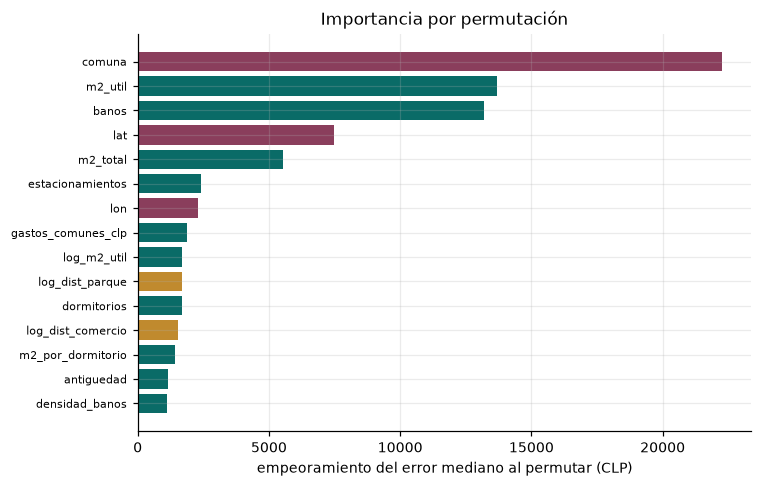

In [13]:
from sklearn.inspection import permutation_importance

# n_jobs=1 a proposito: con -1 revienta en Windows por el memmapping de joblib.
muestra = np.random.default_rng(SEMILLA).choice(len(X_test), min(1500, len(X_test)),
                                                replace=False)
imp = permutation_importance(modelo_final, X_test.iloc[muestra], y_test[muestra],
                             n_repeats=5, random_state=SEMILLA, n_jobs=1,
                             scoring="neg_median_absolute_error")
orden = pd.Series(imp.importances_mean, index=X_test.columns).sort_values(ascending=False)

BLOQUE = {**{c: "estructural" for c in ESTRUCTURALES},
          **{c: "ubicacion" for c in UBICACION_NUM + UBICACION_CAT},
          **{c: "vecindario" for c in VECINDARIO}}

print("=== las 15 variables mas influyentes ===")
for v, s in orden.head(15).items():
    print(f"  ${s:>10,.0f}   [{BLOQUE.get(v,'?'):<12}] {v}")

por_bloque = orden.clip(lower=0).groupby(orden.index.map(BLOQUE)).sum().sort_values(ascending=False)
print("\n=== aporte total por bloque hedonico ===")
for b, s in por_bloque.items():
    print(f"  {b:<14} ${s:>10,.0f}   ({100*s/por_bloque.sum():.0f}%)")
pct_vec = 100 * por_bloque.get("vecindario", 0) / por_bloque.sum()
print(f"\nvecindario: {pct_vec:.0f}% aqui contra 5% en venta.")
if pct_vec >= 8:
    print("La hipotesis se confirma: los servicios cercanos pesan mas en arriendo que")
    print("en venta. Tiene sentido economico: quien arrienda usa el barrio a diario y")
    print("no compra plusvalia futura. Aun asi el bloque sigue siendo el menor de los")
    print("tres, y parte de la ubicacion ya viaja dentro de lat, lon y comuna.")
else:
    print("La hipotesis NO se confirma: el vecindario aporta tan poco como en venta.")
    print("Lo mas probable es que lat, lon y comuna ya capturen esa informacion.")

fig, ax = plt.subplots(figsize=(7, 4.5))
top = orden.head(15)[::-1]
ax.barh(range(len(top)), top.to_numpy(),
        color=[COLORES[["estructural", "ubicacion", "vecindario"].index(BLOQUE.get(v, "estructural"))]
               for v in top.index])
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=7)
ax.set_xlabel("empeoramiento del error mediano al permutar (CLP)")
ax.set_title("Importancia por permutación")
plt.tight_layout(); plt.show()

## Paso 10 — El rango esperado, no un número solo

Decir «esta propiedad se arrienda en $612.000» es falsa precisión. El producto necesita un
**rango**, igual que los informes de tasación comerciales, que publican mínimo, valor recomendado y
máximo.

Se entrenan dos modelos más con **regresión cuantílica** —percentiles 10 y 90—. En teoría el
intervalo entre ambos debería contener el arriendo real el 80 % de las veces. **En la práctica no
lo hace**: en el modelo de venta cubría solo el 66 % cuando prometía 80 %.

Por eso se aplica encima una **calibración conforme** (Romano et al., *Conformalized Quantile
Regression*, NeurIPS 2019): se aparta un trozo del entrenamiento que los modelos cuantílicos no
ven, se mide en él cuánto se quedan cortos, y se ensancha el intervalo en esa cantidad. Eso
garantiza la cobertura en muestra finita sin suponer nada sobre la distribución del error.

El corte de calibración respeta los **grupos de edificio**: si un departamento de la torre quedara
en el propio-entrenamiento y otro en la calibración, la garantía se rompería.

propio-entrenamiento 3,360 - calibracion 1,059



  cuantil 10% entrenado


  cuantil 90% entrenado

correccion conforme: $27,149 (el intervalo se ensancha esa cantidad a cada lado)



                            cobertura   ancho mediano
------------------------------------------------------
cuantilica sola                 65.1%             22%
+ calibracion conforme          81.2%             34%
objetivo                          80%

El intervalo se ensancha: es el precio de que la cobertura sea real.

cobertura por fuente:
  cp: 85.5%  (n=242)
  pi: 80.1%  (n=1,001)


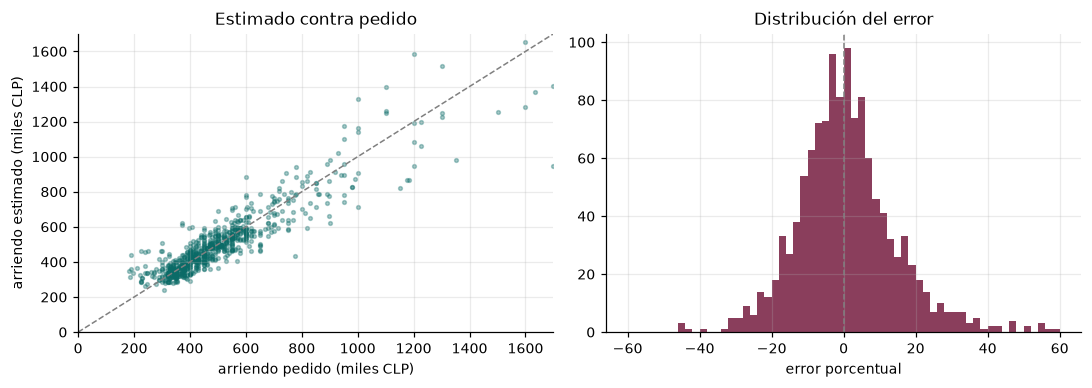

In [14]:
ALFA = 0.20   # se busca 1-ALFA = 80% de cobertura

sep_cal = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEMILLA)
i_prop, i_cal = next(sep_cal.split(X_train, y_train,
                                   groups=datos.loc[i_train, "edificio"]))
X_prop, y_prop = X_train.iloc[i_prop], y_train[i_prop]
X_cal, y_cal = X_train.iloc[i_cal], y_train[i_cal]
print(f"propio-entrenamiento {len(i_prop):,} - calibracion {len(i_cal):,}\n")

Q_BAJO, Q_ALTO = ALFA / 2, 1 - ALFA / 2
cuantiles = {}
for q in (Q_BAJO, Q_ALTO):
    m = envolver(HistGradientBoostingRegressor(
        loss="quantile", quantile=q, max_iter=400, learning_rate=0.06,
        max_leaf_nodes=31, min_samples_leaf=20, random_state=SEMILLA), False)
    m.fit(X_prop, y_prop)
    cuantiles[q] = m
    print(f"  cuantil {q:.0%} entrenado")

# --- Calibracion conforme ----------------------------------------------------
# E_i mide cuanto se quedo corto el intervalo en cada caso de calibracion:
# positivo si el valor real cayo fuera, negativo si cayo comodamente dentro.
lo_cal = cuantiles[Q_BAJO].predict(X_cal)
hi_cal = cuantiles[Q_ALTO].predict(X_cal)
E = np.maximum(lo_cal - y_cal, y_cal - hi_cal)
n_cal = len(E)
k = int(np.ceil((n_cal + 1) * (1 - ALFA)))
CORRECCION = float(np.sort(E)[min(k, n_cal) - 1])
print(f"\ncorreccion conforme: ${CORRECCION:,.0f} "
      f"(el intervalo se ensancha esa cantidad a cada lado)")


def intervalo(entrada):
    """Rango esperado, ya calibrado."""
    lo = cuantiles[Q_BAJO].predict(entrada) - CORRECCION
    hi = cuantiles[Q_ALTO].predict(entrada) + CORRECCION
    return np.maximum(lo, 0), hi


# --- Comprobacion en el conjunto de prueba -----------------------------------
p10_sc = cuantiles[Q_BAJO].predict(X_test)
p90_sc = cuantiles[Q_ALTO].predict(X_test)
cob_sin = 100 * np.mean((y_test >= p10_sc) & (y_test <= p90_sc))

p10, p90 = intervalo(X_test)
dentro = (y_test >= p10) & (y_test <= p90)
cob_con = 100 * dentro.mean()

print(f"\n{'':<26}{'cobertura':>11}{'ancho mediano':>16}")
print("-" * 54)
print(f"{'cuantilica sola':<26}{cob_sin:>10.1f}%"
      f"{np.median(100*(p90_sc-p10_sc)/pred_test):>15.0f}%")
print(f"{'+ calibracion conforme':<26}{cob_con:>10.1f}%"
      f"{np.median(100*(p90-p10)/pred_test):>15.0f}%")
print(f"{'objetivo':<26}{100*(1-ALFA):>10.0f}%")
print("\nEl intervalo se ensancha: es el precio de que la cobertura sea real.")

# La cobertura tambien tiene que cumplirse en la fuente incompleta, no solo en promedio
print("\ncobertura por fuente:")
for s, g in pd.DataFrame({"sitio": prueba["sitio"].to_numpy(), "dentro": dentro}).groupby("sitio"):
    print(f"  {s}: {100*g['dentro'].mean():.1f}%  (n={len(g):,})")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.6))
s = np.random.default_rng(SEMILLA).choice(len(y_test), min(800, len(y_test)), replace=False)
a1.scatter(y_test[s] / 1000, pred_test[s] / 1000, s=6, alpha=0.35, color=COLORES[0])
lim = [0, np.percentile(y_test, 99) / 1000]
a1.plot(lim, lim, "--", color="gray", lw=1)
a1.set_xlim(lim); a1.set_ylim(lim)
a1.set_xlabel("arriendo pedido (miles CLP)"); a1.set_ylabel("arriendo estimado (miles CLP)")
a1.set_title("Estimado contra pedido")

a2.hist(100 * (pred_test - y_test) / y_test, bins=60, range=(-60, 60), color=COLORES[1])
a2.axvline(0, color="gray", ls="--", lw=1)
a2.set_xlabel("error porcentual"); a2.set_title("Distribución del error")
plt.tight_layout(); plt.show()

## Paso 11 — La función del producto

Esta es la pieza que consumirá el backend: recibe los atributos de una propiedad y devuelve el
arriendo estimado, el rango esperado y un **nivel de confianza**.

La confianza no es un adorno. El diagnóstico del Paso 8 mostró que el error no es igual para todos:
las casas son 200 contra 5.462 departamentos y el modelo sabe poco de ellas, y el 23 % sin
coordenadas se estima solo con cinco campos. En vez de dar un número con el mismo aire de certeza
en los tres casos, la función **declara el error típico del segmento al que pertenece la
propiedad**, medido sobre el conjunto de prueba, y marca tres motivos posibles de menor confianza:

- **es una casa** — el modelo apenas vio 190;
- **no tiene coordenadas** — se estima sin ubicación fina ni servicios cercanos;
- **el barrio es inédito** — no hay ningún aviso de entrenamiento en esa celda de ~110 m.

In [15]:
MDAPE_MODELO = float(tabla.loc[GANADOR, "MdAPE"])

# Error tipico por segmento, medido en el conjunto de prueba. Si un segmento tiene
# muy pocos casos su mediana no es fiable y se cae al error global.
def _mdape_de(mascara, minimo=30):
    sub = prueba.loc[mascara, "ape"]
    return float(sub.median()) if len(sub) >= minimo else MDAPE_MODELO

MDAPE_CASA = _mdape_de(prueba["tipo"] == "casa")
MDAPE_SIN_GEO = _mdape_de(prueba["lat"].isna())
N_CASA_TEST = int((prueba["tipo"] == "casa").sum())

# Celdas de ~110 m con al menos un aviso de entrenamiento: define "barrio conocido".
_tr = datos.loc[i_train]
_geo_tr = _tr[_tr["lat"].notna() & _tr["lon"].notna()]
CELDAS_TRAIN = set(_geo_tr["lat"].round(3).astype(str) + ","
                   + _geo_tr["lon"].round(3).astype(str))
COMUNAS_TRAIN = set(_tr["comuna"].dropna())

print(f"error tipico global      : {MDAPE_MODELO:.2f}%")
print(f"error tipico en casas    : {MDAPE_CASA:.2f}%  (n={N_CASA_TEST} en prueba)")
print(f"error tipico sin geo     : {MDAPE_SIN_GEO:.2f}%")
print(f"celdas conocidas         : {len(CELDAS_TRAIN):,}")

error tipico global      : 7.75%
error tipico en casas    : 11.81%  (n=46 en prueba)
error tipico sin geo     : 9.91%
celdas conocidas         : 1,034


In [16]:
def estimar_arriendo(atributos: dict) -> dict:
    """Estima el arriendo mensual de una propiedad.

    `atributos` acepta las columnas crudas del dataset (m2_util, dormitorios,
    banos, comuna, tipo, lat, lon, ano_construccion...) y, opcionalmente,
    `servicios_cercanos` como el JSON que devuelve la API de Places. Lo que
    falte queda en NaN: el modelo lo maneja, pero baja la confianza.
    """
    fila = pd.DataFrame([atributos])
    for c in NUMERICAS + ["servicios_cercanos", "tipo", "comuna"]:
        if c not in fila.columns:
            fila[c] = np.nan
    for c in NUMERICAS:
        fila[c] = pd.to_numeric(fila[c], errors="coerce")
    fila = construir_features(fila)
    for c in TODAS:
        if c not in fila.columns:
            fila[c] = np.nan
    entrada = fila[TODAS]

    estimado = float(modelo_final.predict(entrada)[0])
    lo, hi = intervalo(entrada)
    lo, hi = float(lo[0]), float(hi[0])

    # --- confianza ------------------------------------------------------------
    motivos, error = [], MDAPE_MODELO
    es_casa = str(atributos.get("tipo", "")).lower() == "casa"
    tiene_geo = pd.notna(fila["lat"].iloc[0]) and pd.notna(fila["lon"].iloc[0])

    if es_casa:
        motivos.append(f"es una casa: el modelo se entreno con solo "
                       f"{int((df['tipo']=='casa').sum())} casas contra "
                       f"{int((df['tipo']=='departamento').sum()):,} departamentos")
        error = max(error, MDAPE_CASA)
    if not tiene_geo:
        motivos.append("sin coordenadas: se estima sin ubicacion fina ni servicios cercanos")
        error = max(error, MDAPE_SIN_GEO)
    else:
        celda = f"{round(float(fila['lat'].iloc[0]), 3)},{round(float(fila['lon'].iloc[0]), 3)}"
        if celda not in CELDAS_TRAIN:
            motivos.append("barrio inedito: no hay avisos de entrenamiento a menos de ~110 m")
    if str(atributos.get("comuna", "")) not in COMUNAS_TRAIN:
        motivos.append("comuna fuera de las cuatro cubiertas por el modelo")

    # Una casa es motivo suficiente por si sola: es el segmento peor estimado.
    if es_casa or len(motivos) >= 2:
        confianza = "baja"
    elif motivos:
        confianza = "media"
    else:
        confianza = "alta"

    return {
        "arriendo_estimado_clp": int(round(estimado, -3)),
        "rango_esperado_clp": (int(round(lo, -3)), int(round(hi, -3))),
        "arriendo_estimado_uf": round(estimado / UF, 2),
        "confianza": confianza,
        "motivos_menor_confianza": motivos,
        "error_tipico_pct": round(error, 1),
        "cobertura_del_rango_pct": round(float(cob_con), 1),
    }


# Se prueba con propiedades REALES del conjunto de prueba, que el modelo nunca vio.
# Se toma una de cada situacion para ver los tres niveles de confianza.
casos = []
for etiqueta, mascara in [
        ("departamento con datos completos", (prueba["tipo"] == "departamento") & prueba["lat"].notna()),
        ("departamento sin geo (fuente incompleta)", prueba["lat"].isna()),
        ("casa", prueba["tipo"] == "casa")]:
    sub = prueba[mascara]
    if len(sub):
        casos.append((etiqueta, sub.sample(1, random_state=7).iloc[0]))

CAMPOS_ENTRADA = ["m2_util", "m2_total", "dormitorios", "banos", "estacionamientos",
                  "bodegas", "ano_construccion", "gastos_comunes_clp", "lat", "lon",
                  "comuna", "tipo", "servicios_cercanos"]

for etiqueta, p in casos:
    r = estimar_arriendo({c: p[c] for c in CAMPOS_ENTRADA})
    real = float(p["precio_clp"])
    print(f"\n{'='*72}\n{etiqueta.upper()}")
    print(f"{p['tipo']} en {p['comuna']} - {p['m2_util']:.0f} m2 - "
          f"{p['dormitorios'] if pd.notna(p['dormitorios']) else '?'} dorm - "
          f"{p['banos'] if pd.notna(p['banos']) else '?'} banos")
    print("=" * 72)
    print(f"   arriendo pedido   : ${real:>11,.0f}")
    print(f"   arriendo estimado : ${r['arriendo_estimado_clp']:>11,}   "
          f"(UF {r['arriendo_estimado_uf']:.2f})")
    print(f"   rango esperado    : ${r['rango_esperado_clp'][0]:,} - "
          f"${r['rango_esperado_clp'][1]:,}")
    print(f"   error del segmento: {r['error_tipico_pct']:>10.1f}%")
    print(f"   CONFIANZA         : {r['confianza'].upper()}")
    for m in r["motivos_menor_confianza"]:
        print(f"      - {m}")
    print(f"   desviacion real   : {100*(r['arriendo_estimado_clp']-real)/real:>+9.1f}%")


DEPARTAMENTO CON DATOS COMPLETOS
departamento en san-miguel - 31 m2 - 1.0 dorm - 1.0 banos
   arriendo pedido   : $    329,000
   arriendo estimado : $    309,000   (UF 7.57)
   rango esperado    : $272,000 - $380,000
   error del segmento:        7.8%
   CONFIANZA         : ALTA
   desviacion real   :      -6.1%

DEPARTAMENTO SIN GEO (FUENTE INCOMPLETA)
departamento en nunoa - 32 m2 - 1.0 dorm - 1.0 banos
   arriendo pedido   : $    450,000
   arriendo estimado : $    407,000   (UF 9.96)
   rango esperado    : $324,000 - $527,000
   error del segmento:        9.9%
   CONFIANZA         : MEDIA
      - sin coordenadas: se estima sin ubicacion fina ni servicios cercanos
   desviacion real   :      -9.6%

CASA
casa en la-florida - 70 m2 - 3.0 dorm - 1.0 banos
   arriendo pedido   : $    590,000
   arriendo estimado : $    638,000   (UF 15.62)
   rango esperado    : $491,000 - $727,000
   error del segmento:       11.8%
   CONFIANZA         : BAJA
      - es una casa: el modelo se entreno

## Paso 12 — Guardar para el despliegue

Se serializa todo lo que la API va a necesitar: el modelo, los dos cuantiles, la corrección
conforme, la lista de variables en su orden exacto, y los errores por segmento con los que la
función construye el nivel de confianza.

La ficha JSON hermana deja registrado con qué datos y con qué resultados se entrenó —incluidos los
**sesgos declarados**, que son parte del entregable y no una nota al pie—.

In [17]:
from datetime import datetime

g_prd = tabla.loc[GANADOR, "PRD"]

paquete = {
    "modelo": modelo_final,
    "cuantil_bajo": cuantiles[Q_BAJO],
    "cuantil_alto": cuantiles[Q_ALTO],
    "correccion_conforme": CORRECCION,
    "alfa": ALFA,
    "columnas": TODAS,
    "categorias_poi": CATEGORIAS_POI,
    "mdape": MDAPE_MODELO,
    "mdape_casa": MDAPE_CASA,
    "mdape_sin_geo": MDAPE_SIN_GEO,
    "celdas_train": CELDAS_TRAIN,
    "comunas_train": COMUNAS_TRAIN,
    "uf_referencia": UF,
    "anio_referencia": ANIO,
}
ruta = MODELOS / "arriendo.joblib"
joblib.dump(paquete, ruta)

por_sitio_dict = prueba.groupby("sitio").apply(resumen, include_groups=False).round(3).to_dict("index")
por_tipo_dict = prueba.groupby("tipo").apply(resumen, include_groups=False).round(3).to_dict("index")

ficha = {
    "objetivo": "precio_clp", "operacion": "arriendo",
    "fecha": datetime.now().isoformat(timespec="seconds"),
    "algoritmo": GANADOR,
    "n_total": int(len(X)), "n_train": int(len(i_train)), "n_test": int(len(i_test)),
    "division": "80/20 agrupado por edificio (GroupShuffleSplit)",
    "semilla": SEMILLA,
    "metricas_test": {k: round(float(v), 3) for k, v in tabla.loc[GANADOR].items()},
    "piso_mediana_mdape": round(float(base["MdAPE"]), 2),
    "equidad_vertical": vertical.loc[GANADOR].round(3).to_dict(),
    "metricas_por_fuente": por_sitio_dict,
    "metricas_por_tipo": por_tipo_dict,
    "cobertura_intervalo_80": round(float(cob_con), 1),
    "cobertura_sin_calibrar": round(float(cob_sin), 1),
    "aporte_por_bloque_pct": {k: round(100 * v / por_bloque.sum(), 1)
                              for k, v in por_bloque.items()},
    "variables": {"estructurales": ESTRUCTURALES,
                  "ubicacion": UBICACION_NUM + UBICACION_CAT,
                  "vecindario": VECINDARIO},
    "comparacion_modelos": tabla.reset_index().to_dict("records"),
    "sesgos_declarados": [
        "Precios de publicacion, no de cierre: el modelo estima arriendo PEDIDO esperado. "
        "En Chile el sesgo tipico es de 5-15% sobre el valor de cierre.",
        "Sesgo de seleccion invertido: el dataset es una foto del stock publicado. Lo bien "
        "valorado se arrienda rapido y desaparece del stock; lo sobrevalorado se acumula.",
        f"Dos poblaciones distintas: {100*(1-df['lat'].isna().mean()):.0f}% con datos completos "
        f"y {100*df['lat'].isna().mean():.0f}% con solo cinco campos (comuna, tipo, superficie "
        "util, dormitorios, banos). Ver metricas_por_fuente.",
        f"Casi no hay casas: {int((df['tipo']=='casa').sum())} contra "
        f"{int((df['tipo']=='departamento').sum()):,} departamentos. Las estimaciones de casa "
        "se marcan de baja confianza.",
        "Sin dispersion temporal: 3 fechas de scrape en 15 dias y la UF vario 0,16%. No procede "
        "ajuste temporal, y deflactar por fecha_publicacion seria un error metodologico.",
        "Las categorias comercio, salud y educacion son proxies de densidad comercial, no malls, "
        "hospitales ni colegios en sentido estricto. Solo metro es un catalogo verificado.",
        f"Regresivo en los extremos: PRD {float(g_prd):.3f}, por encima de la banda IAAO "
        f"(0,98-1,03). Subvalora el 20% de arriendos mas caros (ratio mediano "
        f"{float(vertical.loc[GANADOR, 'ratio_20%_mas_caro']):.2f}) y sobrevalora el 20% mas "
        f"barato (ratio {float(vertical.loc[GANADOR, 'ratio_20%_mas_barato']):.2f}). Se probaron "
        f"{len(variantes)} variantes de algoritmo y forma funcional y ninguna entro en banda.",
        "No estima plusvalia ni crecimiento del sector: el dataset es una foto de 15 dias.",
    ],
}
(MODELOS / "arriendo.json").write_text(
    json.dumps(ficha, indent=2, ensure_ascii=False, default=str), encoding="utf-8")

print(f"modelo : {ruta}  ({ruta.stat().st_size/1e6:.1f} MB)")
print(f"ficha  : {MODELOS/'arriendo.json'}")

# Comprobacion de que lo guardado funciona al recargarse
p = joblib.load(ruta)
prueba_carga = p["modelo"].predict(X_test.iloc[[0]])[0]
igual = abs(prueba_carga - pred_test[0]) < 1
print(f"\nverificacion de recarga: ${prueba_carga:,.0f} (esperado ${pred_test[0]:,.0f})  "
      f"{'OK' if igual else 'DIFIERE'}")
assert igual, "el paquete recargado no reproduce la prediccion"

modelo : modelos\arriendo.joblib  (4.9 MB)
ficha  : modelos\arriendo.json

verificacion de recarga: $1,418,570 (esperado $1,418,570)  OK


In [18]:
# --- Criterios de aceptacion, comprobados uno por uno -------------------------
g = tabla.loc[GANADOR]
criterios = [
    ("MdAPE < 15%", g["MdAPE"] < 15, f"{g['MdAPE']:.2f}%"),
    ("MdAPE < 10% (esperado por ser arriendo)", g["MdAPE"] < 10, f"{g['MdAPE']:.2f}%"),
    ("PPE10 > 50%", g["PPE10"] > 50, f"{g['PPE10']:.1f}%"),
    ("COD < 15", g["COD"] < 15, f"{g['COD']:.1f}"),
    ("PRD en 0,98 - 1,03", 0.98 <= g["PRD"] <= 1.03, f"{g['PRD']:.3f}"),
    ("cobertura del intervalo cerca de 80%", abs(cob_con - 80) <= 5, f"{cob_con:.1f}%"),
    ("ninguna columna prohibida", not set(TODAS) & PROHIBIDAS, f"{len(TODAS)} features"),
    ("el paquete recarga y predice igual", igual, "OK"),
]
print(f"{'criterio':<44}{'':<4}{'valor'}")
print("-" * 68)
for nombre, ok, valor in criterios:
    print(f"{nombre:<44}{'OK ' if ok else 'NO '} {valor}")
n_ok = sum(c[1] for c in criterios)
print(f"\n{n_ok}/{len(criterios)} criterios cumplidos")
if not (0.98 <= g["PRD"] <= 1.03):
    print(f"\nEl unico criterio no cumplido es el PRD ({g['PRD']:.3f} contra un maximo de")
    print(f"1,03). No es un descuido: se probaron {len(variantes)} variantes adicionales y")
    print(f"ninguna bajo de {mejor_prd:.3f}. El modelo subvalora el 20% de arriendos mas")
    print("caros y sobrevalora el 20% mas barato; queda declarado como sesgo conocido.")

criterio                                        valor
--------------------------------------------------------------------
MdAPE < 15%                                 OK  7.75%
MdAPE < 10% (esperado por ser arriendo)     OK  7.75%
PPE10 > 50%                                 OK  59.9%
COD < 15                                    OK  11.6
PRD en 0,98 - 1,03                          NO  1.032
cobertura del intervalo cerca de 80%        OK  81.2%
ninguna columna prohibida                   OK  35 features
el paquete recarga y predice igual          OK  OK

7/8 criterios cumplidos

El unico criterio no cumplido es el PRD (1.032 contra un maximo de
1,03). No es un descuido: se probaron 5 variantes adicionales y
ninguna bajo de 1.031. El modelo subvalora el 20% de arriendos mas
caros y sobrevalora el 20% mas barato; queda declarado como sesgo conocido.


---

## Qué sigue

Con los dos modelos ya construidos —venta sobre `precio_uf` y arriendo sobre `precio_clp`— queda
disponible la tercera pregunta del producto:

1. **El yield**: `arriendo_anual / precio_de_venta`, y la comparación contra el dividendo
   hipotecario. Es aritmética sobre las dos estimaciones, pero **hay que propagar los dos errores**:
   un yield calculado con dos modelos de ~9 % de error no se puede reportar con dos decimales.
2. **La API en DigitalOcean**: `modelos/arriendo.joblib` contiene todo lo necesario y
   `estimar_arriendo()` es literalmente el cuerpo del endpoint.
3. **Explicabilidad por propiedad**, para que el informe diga *por qué* esa estimación. `shap` no
   tiene wheel para Python 3.14, pero la misma implementación en C++ se obtiene del booster nativo
   de LightGBM (`pred_contrib=True`) o XGBoost (`pred_contribs=True`).

**Lo que este dataset no permite** y conviene no prometer: plusvalía, tiempo esperado de colocación
y transacciones efectivas del CBR —las tres secciones que traen los informes comerciales de
tasación—. Todas exigen series históricas o registros de cierre, y aquí hay una foto de 15 días de
avisos publicados.